In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
df = pd.read_csv("D:/AKRAM/data analysis project/Financial-Analytics-data1.csv")
print(df.shape)
df.head()

(459, 5)


,Name,Mar Cap - Crore,Sales Qtr - Crore,Market_Cap_Category,Sales_Qrt_Category
0,Reliance Inds.,583436.72,99810.00,Large Cap,High Sales
1,TCS,563709.84,30904.00,Large Cap,High Sales
2,HDFC Bank,482953.59,20581.27,Large Cap,High Sales
3,ITC,320985.27,9772.02,Large Cap,High Sales
4,H D F C,289497.37,16840.51,Large Cap,High Sales


In [4]:
print(df.isnull().sum())
print(df.dtypes)
df.describe().round(2)


Name                   0
MarketCap              0
Sales                  0
Market_Cap_Category    0
Sales_Qrt_Category     0
dtype: int64
Name                    object
MarketCap              float64
Sales                  float64
Market_Cap_Category     object
Sales_Qrt_Category      object
dtype: object


,MarketCap,Sales
count,459.00,459.00
mean,28870.97,3807.79
std,60557.08,9989.45
min,3017.07,0.00
25%,4942.82,534.91
50%,10442.09,1137.17
75%,24707.32,2730.20
max,583436.72,110666.93


In [5]:
df.rename(columns={ 'Mar Cap - Crore': 'MarketCap', 'Sales Qtr - Crore': 'Sales' },
inplace=True)

In [6]:
df['PS_Ratio'] = df['MarketCap'] / df['Sales'].replace(0, np.nan)
df['PS_Ratio'] = df['PS_Ratio'].round(2)
print(df[['Name','MarketCap','Sales','PS_Ratio']].head(10))

             Name  MarketCap     Sales  PS_Ratio
0  Reliance Inds.  583436.72  99810.00      5.85
1             TCS  563709.84  30904.00     18.24
2       HDFC Bank  482953.59  20581.27     23.47
3             ITC  320985.27   9772.02     32.85
4         H D F C  289497.37  16840.51     17.19
5  Hind. Unilever  288265.26   8590.00     33.56
6   Maruti Suzuki  263493.81  19283.20     13.66
7         Infosys  248320.35  17794.00     13.96
8         O N G C  239981.50  22995.88     10.44
9  St Bk of India  232763.33  57014.08      4.08


In [10]:
def ps_label(x):
    if x <= 5:
        return 'Undervalued'
    elif x <= 20:
        return 'Fair Value'
    else:
        return 'Overvalued'

df['Valuation'] = df['PS_Ratio'].apply(ps_label)
print(df['Valuation'].value_counts())



Valuation
Fair Value     265
Overvalued      97
Undervalued     97
Name: count, dtype: int64


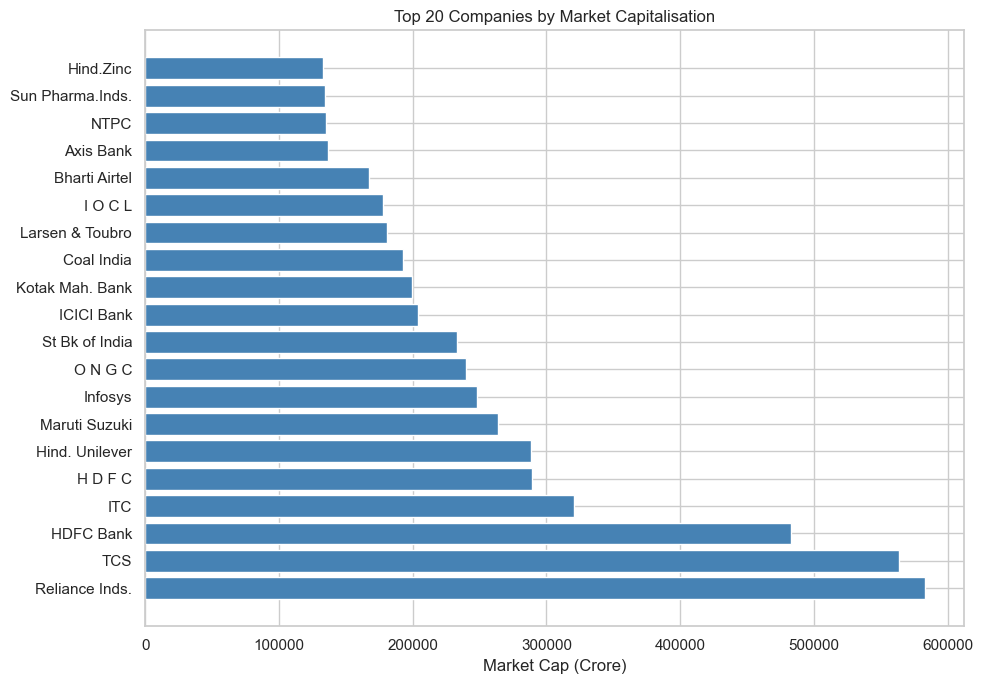

In [11]:
top20 = df.nlargest(20, 'MarketCap')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['Name'], top20['MarketCap'], color='steelblue')

ax.set_xlabel('Market Cap (Crore)')
ax.set_title('Top 20 Companies by Market Capitalisation')

plt.tight_layout()
plt.savefig('top20_market_cap.png', dpi=150)
plt.show()


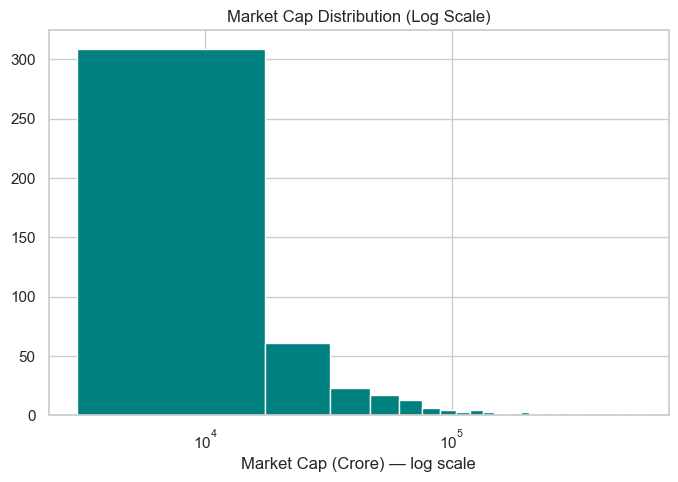

In [12]:
plt.figure(figsize=(8,5)) 
plt.hist(df['MarketCap'], bins=40, color='teal', edgecolor='white') 
plt.xscale('log') 
plt.title('Market Cap Distribution (Log Scale)') 
plt.xlabel('Market Cap (Crore) — log scale') 
plt.savefig('marketcap_dist.png', dpi=150) 
plt.show()


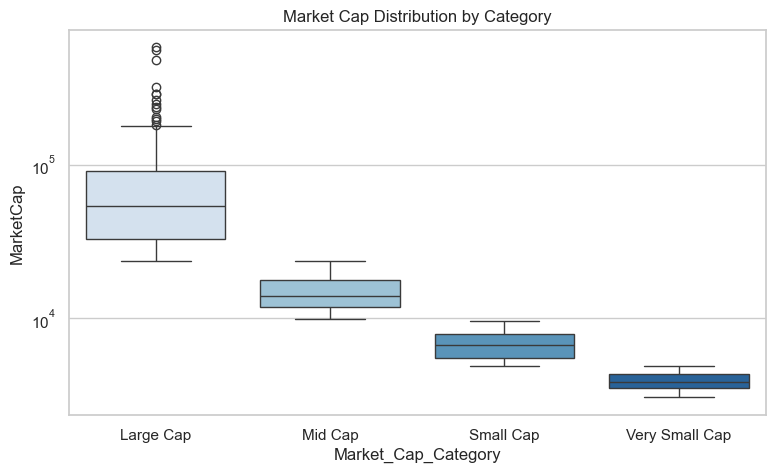

In [14]:
order = ['Large Cap','Mid Cap','Small Cap','Very Small Cap']

plt.figure(figsize=(9,5))
sns.boxplot(
    data=df, 
    x='Market_Cap_Category', 
    y='MarketCap', 
    hue='Market_Cap_Category',
    order=order, 
    palette='Blues'
)

plt.yscale('log')
plt.title('Market Cap Distribution by Category')
plt.savefig('boxplot_category.png', dpi=150)
plt.show()


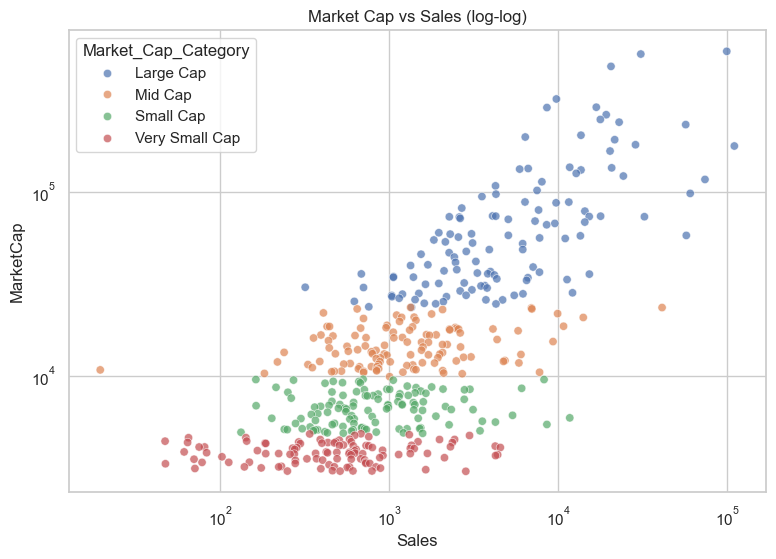

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x='Sales',
    y='MarketCap',
    hue='Market_Cap_Category',
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.title('Market Cap vs Sales (log-log)')
plt.savefig('scatter_cap_sales.png', dpi=150)
plt.show()


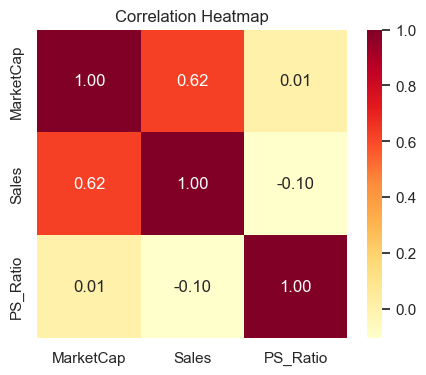

In [16]:
plt.figure(figsize=(5,4))
sns.heatmap(
    df[['MarketCap','Sales','PS_Ratio']].corr(),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)
plt.title('Correlation Heatmap')
plt.savefig('heatmap.png', dpi=150)
plt.show()
